In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from scipy import ndimage
from scipy.stats import linregress
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)

# 0. Калибровка

In [68]:
k_cam = 1000/911 #мкм/pix

# 1. Дифракция Френеля
## Обработка фото

In [245]:
def rescale(path_in, path_out):
    img = np.array(Image.open(path_in).convert("L"), dtype=float)
    H, W = img.shape
    x = np.arange(W)
    I_x = img.sum(axis=0)
    x_center = int((x * I_x).sum() / I_x.sum())
    Image.fromarray(np.clip(img[750:1250, x_center - 400:x_center + 400], 0, 255).astype(np.uint8)).save(path_out)

In [ ]:
rescale("изображения с микроскопа/1 френель/0.jpg", "pics/fren0.jpg")
rescale("изображения с микроскопа/1 френель/2.jpg", "pics/fren2.jpg")
rescale("изображения с микроскопа/1 френель/3.jpg", "pics/fren3.jpg")
rescale("изображения с микроскопа/1 френель/4.jpg", "pics/fren4.jpg")
rescale("изображения с микроскопа/1 френель/5.jpg", "pics/fren5.jpg")
rescale("изображения с микроскопа/1 френель/7.jpg", "pics/fren7.jpg")


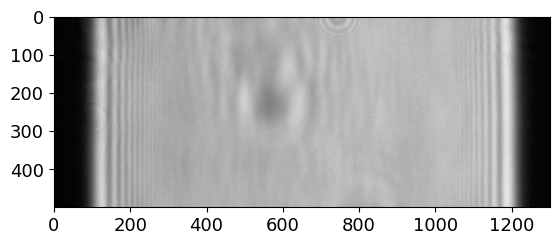

In [273]:
img = np.array(Image.open("изображения с микроскопа/1 френель/0.2.jpg").convert("L"), dtype=float)
plt.imshow(img[750:1250, 600:1900], cmap='gray')
Image.fromarray(np.clip(img[750:1250, 600:1900], 0, 255).astype(np.uint8)).save("pics/1200mkm.jpg")

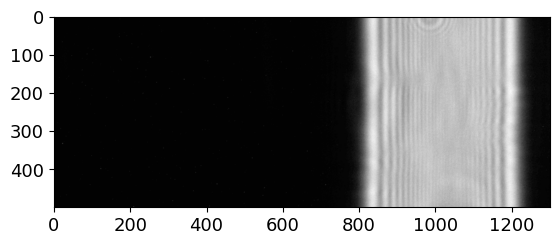

In [272]:
img = np.array(Image.open("изображения с микроскопа/1 френель/0.1.jpg").convert("L"), dtype=float)
plt.imshow(img[750:1250, 360:1660], cmap='gray')
Image.fromarray(np.clip(img[750:1250, 360:1660], 0, 255).astype(np.uint8)).save("pics/400mkm.jpg")

## Зоны френеля

In [210]:
lam = 515 #nm -- длина волны лазера
sigma_lam = 18 #nm -- полуширина спектра
d = 411 * k_cam #mkm -- ширина щели
sigma_d = 2 * k_cam #mkm 
data = pd.read_excel("измерения.xlsx", sheet_name="1 френель на щели")[['n', 'x_min, mm', 'x_max, mm']].drop(0)
data

,n,"x_min, mm","x_max, mm"
1,1,50.00,65.00
2,2,30.00,41.00
3,3,23.00,28.00
4,4,20.00,23.00
5,5,16.00,16.00
6,6,13.31,15.21
7,7,11.45,12.29


In [211]:
data['x_avg, mm'] = (data['x_min, mm'] + data['x_max, mm'])/2
data['sigma_x, mm'] = (((data['x_max, mm'] - data['x_min, mm'])/2)**2 + 2**2)**0.5
data[['n', 'x_avg, mm', 'sigma_x, mm']]

,n,"x_avg, mm","sigma_x, mm"
1,1,57.50,7.762087
2,2,35.50,5.852350
3,3,25.50,3.201562
4,4,21.50,2.500000
5,5,16.00,2.000000
6,6,14.26,2.214159
7,7,11.87,2.043624


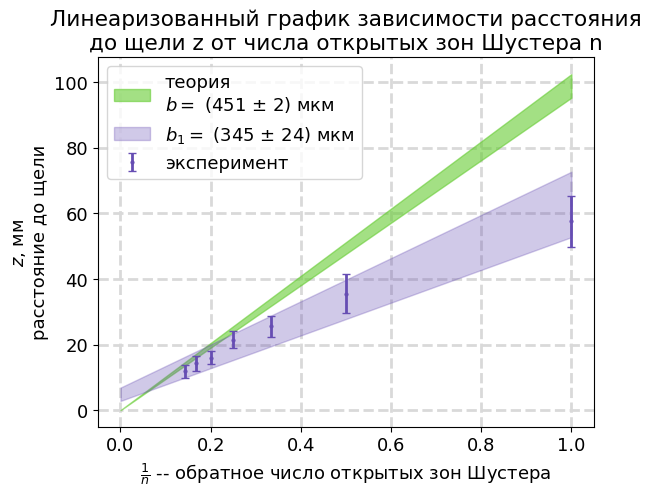

In [274]:
k_th = d**2 / 4 /lam # мм
sigma_k_th = ((2 * sigma_d / d)**2 + (sigma_lam/lam)**2)**0.5*k_th
n_th = np.linspace(0, 1, 2)

def linear(x, k, b):
    return k*x + b
popt, pcov = opt.curve_fit(linear, 
                             1/data["n"], 
                             data["x_avg, mm"], 
                             sigma = data["sigma_x, mm"], 
                             absolute_sigma = True)
k = popt[0]
b = popt[1]
sigma_k = pcov[0][0]**0.5
sigma_b = pcov[1][1]**0.5

d_th = 2 * (lam * k)**0.5
sigma_d_th = ((sigma_k/2/k)**2 + (sigma_lam/2/lam)**2)**0.5 * d_th

plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2, zorder = 0)
plt.fill_between(n_th, (k_th - sigma_k_th) * n_th, (k_th + sigma_k_th) * n_th, 
                 color = light_green, alpha = 0.6, label = 'теория\n' + r'$b = $ ' + f'({d:.0f} ' + r'$\pm$' + f' {sigma_d:.0f}) мкм',
                 zorder = 5)
plt.errorbar(1/data["n"], data["x_avg, mm"], 
             yerr = data["sigma_x, mm"], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'эксперимент',
             color = dark_purple,
             zorder = 5)
plt.fill_between(n_th, (k - sigma_k) * n_th + b - sigma_b, (k + sigma_k) * n_th + b + sigma_b, 
                 color = dark_purple, alpha = 0.3, label = r'$b_1 = $ ' + f'({d_th:.0f} ' + r'$\pm$' + f' {sigma_d_th:.0f}) мкм',
                 zorder = 10)
plt.xlabel(r'$\frac{1}{n}$ -- обратное число открытых зон Шустера')
plt.ylabel(r'$z$, мм' + f'\nрасстояние до щели')
plt.legend(loc = 'upper left')
plt.title('Линеаризованный график зависимости расстояния\nдо щели z от числа открытых зон Шустера n')
plt.savefig('pics/graph1.png', dpi = 300)

## Правдоподобие линейной зависимости

In [277]:
from scipy.stats import chi2 as chi2_dist

x = 1/data["n"]
y = data["x_avg, mm"]
sigma = data["sigma_x, mm"]

y_fit = linear(x, *popt)

chi2 = np.sum(((y - y_fit) / sigma)**2)
dof = len(data["n"]) - 2
p_value = 1 - chi2_dist.cdf(chi2, dof)
p_value

0.8615506196353593

# 2. Дифракция Фраунгофера
## Обработка фото

In [ ]:
img = np.array(Image.open("изображения с микроскопа/2 фраунгофер/1 щель.jpg").convert("L"), dtype=float)

In [22]:
# поворот фото

H, W = img.shape
x = np.arange(W)
threshold = 90

# считаем центр масс по каждой строке
x_centers = []
y_vals = []

for y in range(H):
    row = img[y, :]
    row_mask = row < threshold #убираем пересвет

    if row_mask.sum() == 0:
        continue
    
    weights = row[row_mask]
    xs = x[row_mask]
    
    xc = (xs * weights).sum() / weights.sum()
    
    x_centers.append(xc)
    y_vals.append(y)

x_centers = np.array(x_centers)
y_vals = np.array(y_vals)

Text(0.5, 1.0, 'Середина изображения')

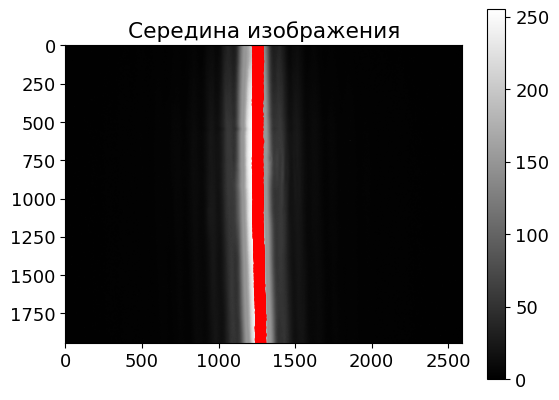

In [24]:
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.plot(x_centers, y_vals, 'o', color = (1.0, 0.0, 0.0))
plt.title("Середина изображения")

In [27]:
# вычисление поворота

# фит прямой x(y) = a*y + b
fit = linregress(y_vals, x_centers)
a = fit.slope
b = fit.intercept

# угол наклона относительно вертикали
phi_rad = np.arctan(a)
phi_deg = np.degrees(phi_rad)

print("slope a =", a)
print("rotation angle (deg) =", phi_deg)

# поворот к норме

rotated = ndimage.rotate(img, -phi_deg, order=3)

# сохранить
Image.fromarray(np.clip(rotated, 0, 255).astype(np.uint8)).save("изображения с микроскопа/2 фраунгофер/rotated.jpg")

slope a = 0.00993302813787652
rotation angle (deg) = 0.5691018737562145


# Усреднение спектра

In [32]:
from scipy.signal import find_peaks

In [160]:
I_avg = rotated.mean(axis=0)
sigma_I_avg = rotated.std(axis=0, ddof=1)/np.sqrt(rotated.shape[0])
I_avg_log = np.log(I_avg)
x = np.arange(rotated.shape[1])
x0 = (x[200:-200] * I_avg[200:-200]).sum() / I_avg[200:-200].sum()
sigma_x0 = np.sqrt(
    ((x[200:-200] - x0)**2 * sigma_I_avg[200:-200]**2).sum()) / I_avg[200:-200].sum()
x0, sigma_x0

(1256.8856990221848, 0.016445613123451438)

In [161]:
# минимумы спектра
min_indices, _ = find_peaks(-I_avg_log, distance=5, prominence=0.035)

C:\Users\user\AppData\Local\Temp\ipykernel_9136\3176203612.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot((x[min_indices]-x0)*k_cam/1000, I_avg_log[min_indices], 'ro',


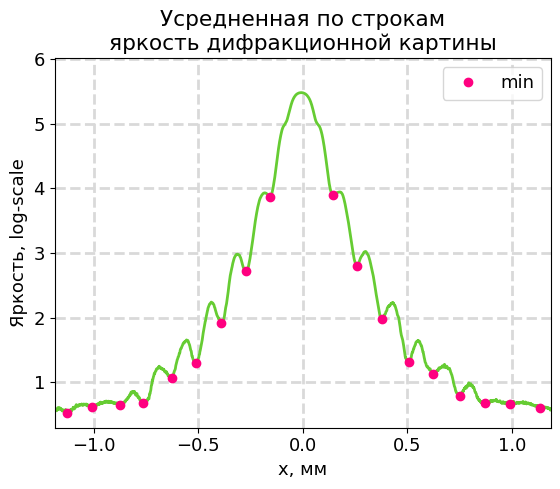

In [162]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.plot((x-x0)*k_cam/1000, I_avg_log, 
         color = light_green)
plt.plot((x[min_indices]-x0)*k_cam/1000, I_avg_log[min_indices], 'ro',
         color = raspberry_pink,
         label = 'min')
plt.title("Усредненная по строкам\nяркость дифракционной картины")
plt.xlabel("x, мм")
plt.ylabel("Яркость, log-scale")
plt.xlim(-1080*k_cam/1000, 1080*k_cam/1000)
plt.ylim(bottom = 0.3)
plt.legend()
plt.savefig("pics/2B(x)", dpi = 300)

In [163]:
x_right = np.sort(x[min_indices[(min_indices >= x0) & (min_indices <= x0 + 1080)]]) - x0
x_left = np.sort(abs(x[min_indices[(min_indices <= x0) & (min_indices >= x0 - 1080)]] - x0))
n = np.arange(1, len(x_right)+1)
x_avg = (x_left + x_right) / 2
sigma_x_avg = abs(x_left - x_right) / 2 

113.44131512868076 0.016226276875153687


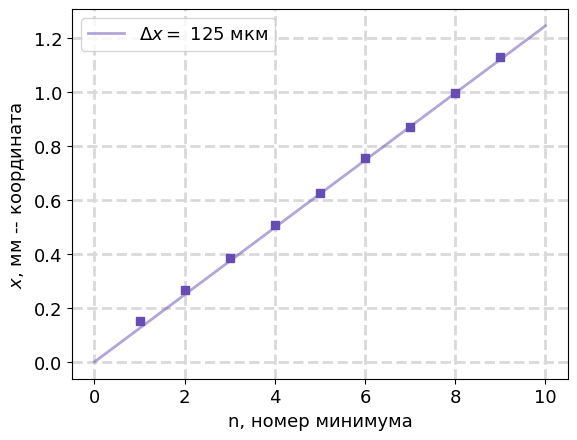

In [165]:
def linear0(x, k):
    return k*x
popt, pcov = opt.curve_fit(linear0, 
                             n, 
                             x_avg, 
                             sigma = sigma_x_avg, 
                             absolute_sigma = True)
k = popt[0]
sigma_k = pcov[0][0]**0.5
print(k, sigma_k)
n_th = np.linspace(0, 10, 2)
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.plot(n, x_avg*k_cam/1000, 's', color = dark_purple)
plt.plot(n_th, k*n_th*k_cam/1000, color = dark_purple, alpha = 0.5, label = r"$\Delta x =$ " + f"{k*k_cam:.0f} мкм")
plt.xlabel('n, номер минимума')
plt.ylabel(r'$x$, мм -- координата')
plt.legend()
plt.savefig("pics/graph2.png", dpi = 300)


In [ ]:
f = 175 #mm -- фокус линзы
sigma_f = 5 #mm
lam = 515 #nm -- длина волны лазера
sigma_lam = 18 #nm -- полуширина спектра
d = lam * f / (k*k_cam/1000)/1000 #мкм -- ширина щели
sigma_d = ((sigma_lam/lam)**2 + (sigma_f/f)**2)**0.5 * d
d, sigma_d

(723.7563748874604, 32.672857725459394)

In [ ]:
343 * k_cam #мкм -- реальная ширина щели

376.5093304061471

In [270]:
img = np.array(Image.open("изображения с микроскопа/2 фраунгофер/rotated.jpg").convert("L"), dtype=float)
H, W = img.shape
x = np.arange(W)
I_x = img.sum(axis=0)
x_center = int((x * I_x).sum() / I_x.sum())
Image.fromarray(np.clip(img[750:1250, x_center - 1080:x_center + 1080], 0, 255).astype(np.uint8)).save("pics/fraun.jpg")

Проволоки